# Progetto: Analisi e Previsione del Successo nel Placement Universitario

**Corso di Programmazione di Applicazioni Data Intensive**

**Lorenzo Antonioli**

## 1. Contesto e Obiettivo
L'obiettivo di questo progetto è addestrare un modello di predizione (nello specifico un modello di classificazione) in grado di stimare se uno studente universitario riceverà o meno un'offerta di lavoro. Il contesto si basa sull'analisi dell'efficacia delle piattaforme di ricerca lavoro (es. LinkedIn, Handshake, Indeed) e su come i fattori legati alla carriera accademica, alle esperienze pregresse (tirocini, attività extracurriculari) e al comportamento attivo nella ricerca (eventi di networking, invio di candidature) influenzino l'occupabilità dei candidati.

### 1.1 Descrizione del Dataset
Il dataset utilizzato è il [Job Board Effectiveness for College Students](https://www.kaggle.com/datasets/likithagedipudi/job-board-effectiveness-for-college-students/data) ricavato da Kaggle.
Il dataset contiene le seguenti variabili:
* `Student_ID`: Stringa che identifica in modo univoco il singolo studente.
* `University_Rating`: Valutazione e posizionamento dell'ateneo (es. Top-tier, Mid-tier, Lower-tier).
* `School_Size`: Dimensione dell'istituto universitario (Small, Medium, Large).
* `Region`: Area geografica di provenienza/studio (es. West, Northeast, Midwest, South).
* `Major_Category`: Ambito di studio accademico (es. STEM, Business, Healthcare, Humanities, Arts).
* `GPA`: Media dei voti dello studente.
* `Prior_Internships`: Il numero di stage o tirocini pregressi.
* `Extra_Curricular_Activities`: Grado di coinvolgimento in attività extracurriculari.
* `Networking_Events_Attended`: Numero di eventi di networking a cui lo studente ha preso parte.
* `Primary_Search_Platform`: La piattaforma principale utilizzata per la ricerca (es. LinkedIn, Indeed, Handshake).
* `Months_Searching`: Durata della ricerca attiva in mesi.
* `Applications_Submitted`: Il numero totale di candidature inviate.
* `First_Round_Interviews`: Numero di primi colloqui ottenuti.
* `Second_Round_Interviews`: Numero di secondi colloqui ottenuti.
* `Offer_Received`: Variabile target binaria da predire (1 = offerta ricevuta, 0 = nessuna offerta).
* `Time_to_Offer_Days`: Giorni impiegati per ricevere la proposta di lavoro.
* `Offer_Salary`: Salario annuale proposto all'interno dell'offerta.
* `Company_Size_Offered`: Dimensione dell'azienda offerente.
* `Role_Relevance`: Grado di pertinenza del ruolo rispetto agli studi fatti.
* `Accepted_Offer`: Variabile binaria che segnala se l'offerta finale è stata accettata.

In [34]:
# Import delle librerie fondamentali
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [10]:
# Configurazione grafica per i plot
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})

# Disabilito i warning per mantenere il notebook pulito
import warnings
warnings.filterwarnings('ignore')

# Caricamento del dataset
try:
    df = pd.read_csv('job_board_effectiveness.csv')
    print("Dataset caricato con successo")
    print(f"Il dataset contiene {df.shape[0]} righe e {df.shape[1]} colonne.")
except FileNotFoundError:
    print("Errore: File non trovato.")

Dataset caricato con successo
Il dataset contiene 100000 righe e 20 colonne.


In [11]:
display(df.head())

,Student_ID,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received,Time_to_Offer_Days,Offer_Salary,Company_Size_Offered,Role_Relevance,Accepted_Offer
0,STU_000001,Mid-tier,Medium,West,Healthcare,2.81,3,2,6,LinkedIn,1,9,2,2,1,46.0,59785.0,Mid-Size,9.0,1.0
1,STU_000002,Lower-tier,Medium,Northeast,STEM,2.61,1,1,6,Handshake,1,5,1,0,0,NaN,NaN,NaN,NaN,NaN
2,STU_000003,Lower-tier,Medium,Midwest,STEM,3.53,3,2,2,Handshake,5,34,3,1,0,NaN,NaN,NaN,NaN,NaN
3,STU_000004,Mid-tier,Medium,Midwest,Business,2.73,0,2,1,Handshake,2,10,0,0,0,NaN,NaN,NaN,NaN,NaN
4,STU_000005,Mid-tier,Medium,South,Business,4.00,1,0,1,Indeed,5,65,0,0,0,NaN,NaN,NaN,NaN,NaN


### 1.2 Prima Scrematura dei Dati

Prima di procedere con l'eliminazione, è opportuno verificare quantitativamente quali variabili presentano un'anomalia predittiva sospetta. Utilizziamo il ROC-AUC univariato come test di leakage: una feature con ROC-AUC molto superiore a 0.5 calcolato rispetto al target suggerisce che quella variabile "conosce" già la risposta.

TOP FEATURE PER ROC-AUC UNIVARIATO (Leak Detection)
                       feature   roc_auc
7      Second_Round_Interviews  0.858197
6       First_Round_Interviews  0.709084
1            Prior_Internships  0.625452
0                          GPA  0.553842
4             Months_Searching  0.530220
5       Applications_Submitted  0.514483
2  Extra_Curricular_Activities  0.503047
3   Networking_Events_Attended  0.500219
8           Time_to_Offer_Days       NaN
9                 Offer_Salary       NaN


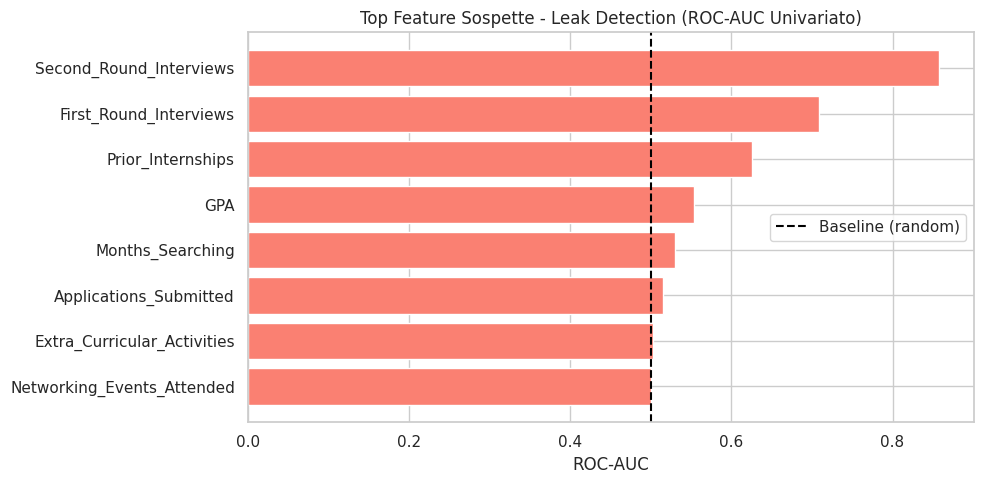

In [12]:
# Eseguiamo il leak detection su tutte le colonne numeriche (escluso il target)
X_full = df.select_dtypes(include=[np.number]).drop(columns=['Offer_Received'], errors='ignore')
y_full = df['Offer_Received']

leak_scores = []
for col in X_full.columns:
    try:
        # Gestiamo i valori nulli per non falsare il test
        mask = X_full[col].notna()
        score = roc_auc_score(y_full[mask], X_full[col][mask])
        leak_scores.append((col, score))
    except:
        continue

leak_df = pd.DataFrame(leak_scores, columns=['feature', 'roc_auc'])
leak_df = leak_df.sort_values(by='roc_auc', ascending=False)
print("TOP FEATURE PER ROC-AUC UNIVARIATO (Leak Detection)")
print(leak_df.head(10))

top_leaks = leak_df.head(10)
plt.figure(figsize=(10, 5))
plt.barh(top_leaks['feature'], top_leaks['roc_auc'], color='salmon')
plt.axvline(x=0.5, color='black', linestyle='--', label='Baseline (random)')
plt.gca().invert_yaxis()
plt.xlabel("ROC-AUC")
plt.title("Top Feature Sospette - Leak Detection (ROC-AUC Univariato)")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretazione del Leak Detection:**

L'analisi rivela due variabili con potere predittivo anomalo:
* **`Second_Round_Interviews` (ROC-AUC ≈ 0.86):** Questo valore è quasi a 1. Nella realtà, un candidato sa di essere stato al secondo colloquio solo dopo aver già iniziato il processo di selezione. È **data leakage**.
* **`First_Round_Interviews` (ROC-AUC ≈ 0.71):** Analogamente, anche il numero di primi colloqui è un'informazione che si accumula durante il processo di selezione.

Le altre variabili (`Prior_Internships`, `GPA`, `Applications_Submitted`, ecc.) mostrano ROC-AUC modesti e vicini a 0.5, il che indica che possono essere utilizzate.

Le variabili `Time_to_Offer_Days`, `Offer_Salary`, `Role_Relevance`, `Accepted_Offer` sono popolate esclusivamente per i record con `Offer_Received = 1` e rappresentano informazioni conseguenti all'offerta stessa: devono essere eliminate.

**Variabili eliminate nella prima scrematura:**
1. `Student_ID`: identificatore senza utilità
2. `First_Round_Interviews`: data leakage (ROC-AUC = 0.71)
3. `Second_Round_Interviews`: data leakage (ROC-AUC = 0.86)
4. `Time_to_Offer_Days`, `Offer_Salary`, `Company_Size_Offered`, `Role_Relevance`, `Accepted_Offer`: informazioni post-offerta, disponibili solo per chi l'ha ricevuta

Nel contesto di questo progetto, è fondamentale distinguere due approcci principali:

*   **Pre-Search Modeling:** Il modello primario e più onesto che ci interessa addestrare. Si basa solo su fattori antecedenti al processo di ricerca del lavoro e ai colloqui (es. GPA, tirocini). Risponde alla domanda: "Dato il profilo accademico e comportamentale di uno studente, qual è la sua probabilità di ricevere un'offerta di lavoro?"

*   **Mid-Search Modeling:** Un modello che include anche variabili che emergono durante il processo di selezione (numero di colloqui). Risponde alla domanda: "Dato il profilo di uno studente *e* il suo avanzamento nel processo di selezione, qual è la sua probabilità di ricevere un'offerta di lavoro?"

È cruciale notare che l'inclusione di variabili come il numero di colloqui introduce un potenziale data leakage se l'obiettivo è predire il successo *prima* che il processo di selezione inizi. Pertanto, il nostro modello principale (sviluppato nelle sezioni 3, 4 e 5) si concentrerà sull'approccio Pre-Search. Il confronto con un modello Mid-Search (Sezione 6) servirà a quantificare il valore informativo di tali variabili e a dimostrare la differenza tra i due scenari predittivi.

In [13]:
useless_columns = [
    'Student_ID',
    'First_Round_Interviews',
    'Second_Round_Interviews',
    'Time_to_Offer_Days',
    'Offer_Salary',
    'Company_Size_Offered',
    'Role_Relevance',
    'Accepted_Offer'
]
df = df.drop(columns=useless_columns)
print(f"Dimensioni del dataset dopo la prima scrematura: {df.shape[0]} righe e {df.shape[1]} colonne")
display(df.head())
display(df.tail())
df.info()

Dimensioni del dataset dopo la prima scrematura: 100000 righe e 12 colonne


,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,Offer_Received
0,Mid-tier,Medium,West,Healthcare,2.81,3,2,6,LinkedIn,1,9,1
1,Lower-tier,Medium,Northeast,STEM,2.61,1,1,6,Handshake,1,5,0
2,Lower-tier,Medium,Midwest,STEM,3.53,3,2,2,Handshake,5,34,0
3,Mid-tier,Medium,Midwest,Business,2.73,0,2,1,Handshake,2,10,0
4,Mid-tier,Medium,South,Business,4.00,1,0,1,Indeed,5,65,0


,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,Offer_Received
99995,Lower-tier,Large,Northeast,STEM,3.61,3,1,1,Handshake,3,15,1
99996,Lower-tier,Large,West,Business,3.39,0,1,4,Indeed,8,120,0
99997,Lower-tier,Small,Northeast,Business,3.38,4,2,2,Indeed,4,60,0
99998,Mid-tier,Large,Midwest,Business,3.20,2,0,0,LinkedIn,7,39,0
99999,Mid-tier,Small,Midwest,STEM,3.62,2,5,7,Handshake,12,5,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   University_Rating            100000 non-null  object 
 1   School_Size                  100000 non-null  object 
 2   Region                       100000 non-null  object 
 3   Major_Category               100000 non-null  object 
 4   GPA                          100000 non-null  float64
 5   Prior_Internships            100000 non-null  int64  
 6   Extra_Curricular_Activities  100000 non-null  int64  
 7   Networking_Events_Attended   100000 non-null  int64  
 8   Primary_Search_Platform      100000 non-null  object 
 9   Months_Searching             100000 non-null  int64  
 10  Applications_Submitted       100000 non-null  int64  
 11  Offer_Received               100000 non-null  int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 9.2+ MB


## 2. Analisi Esplorativa dei Dati (EDA)

In questa fase esploriamo il dataset pulito per comprenderne a fondo le caratteristiche, individuare eventuali anomalie (es. *outlier*) e analizzare le relazioni tra le variabili, con particolare attenzione a come queste influenzano la nostra variabile target `Offer_Received`.

Iniziamo calcolando le statistiche descrittive generali, separando le variabili numeriche da quelle categoriali, per ottenere una prima panoramica su medie, quartili e valori distinti.

In [14]:
print("STATISTICHE VARIABILI NUMERICHE")
display(df.describe().round(2))

print("\nSTATISTICHE VARIABILI CATEGORIALI")
display(df.describe(include=['object']))

STATISTICHE VARIABILI NUMERICHE


,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted,Offer_Received
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,3.20,1.20,2.00,3.00,6.50,53.73,0.34
std,0.39,1.12,1.41,1.73,3.44,45.00,0.47
min,2.00,0.00,0.00,0.00,1.00,5.00,0.00
25%,2.93,0.00,1.00,2.00,4.00,19.00,0.00
50%,3.20,1.00,2.00,3.00,6.00,42.00,0.00
75%,3.47,2.00,3.00,4.00,9.00,75.00,1.00
max,4.00,5.00,11.00,14.00,12.00,300.00,1.00



STATISTICHE VARIABILI CATEGORIALI


,University_Rating,School_Size,Region,Major_Category,Primary_Search_Platform
count,100000,100000,100000,100000,100000
unique,3,3,4,5,3
top,Mid-tier,Large,South,STEM,LinkedIn
freq,50022,40169,25099,35102,39573


Dall'osservazione delle statistiche generali emergono diverse informazioni chiave sul profilo del campione di 100.000 studenti analizzato:

* **Variabile Target (`Offer_Received`):** La media si attesta a 0.34. Essendo una variabile binaria (0 o 1), questo significa che esattamente il **34% degli studenti ha ricevuto un'offerta di lavoro**, mentre il 66% no. Il dataset risulta quindi sbilanciato verso la classe negativa, ma la proporzione della classe positiva (oltre un terzo) è assolutamente sufficiente per addestrare un modello di classificazione senza dover necessariamente ricorrere a tecniche di bilanciamento avanzate (come SMOTE).
* **Profilo Accademico:** Il `GPA` varia tra 2.00 e 4.00 con media 3.20. In media gli studenti hanno maturato almeno 1 tirocinio pregresso (`Prior_Internships`).
* **Comportamento nella ricerca del lavoro:** `Applications_Submitted` mostra forte varianza (deviazione standard ~45): la mediana è di 42 candidature, ma c'è chi ne ha inviate solo 5 e chi arriva a 300. La ricerca dura in media 6-7 mesi.
* **Profilo Categoriale:** Lo studente "tipo" proviene da un'università di fascia media (`Mid-tier`, circa il 50% dei casi) e di grandi dimensioni (`Large`, 40%). L'ambito disciplinare predominante è quello scientifico-tecnologico (`STEM`, 35%).
* **Strumenti e Geografia:** La distribuzione geografica appare molto ben bilanciata tra le 4 regioni, con una lieve prevalenza per il Sud (`South`, ~25%). Infine, per quanto riguarda le piattaforme di ricerca lavoro, `LinkedIn` risulta essere lo strumento principale scelto dai candidati (circa il 40% delle preferenze).

Tutte le variabili presentano un conteggio esatto di 100.000 record, a conferma che non sono presenti dati mancanti (nulli) sulle feature rimanenti.

### 2.1 Distribuzione delle Variabili e Analisi Visiva
Procediamo con la visualizzazione grafica delle distribuzioni. Analizzeremo:
1. La proporzione della variabile target tramite un grafico a torta.
2. Le distribuzioni delle principali variabili categoriali tramite grafici a barre.
3. Le distribuzioni delle variabili continue tramite istogrammi.
4. Il tasso di successo per numero di tirocini e per numero di candidature inviate.

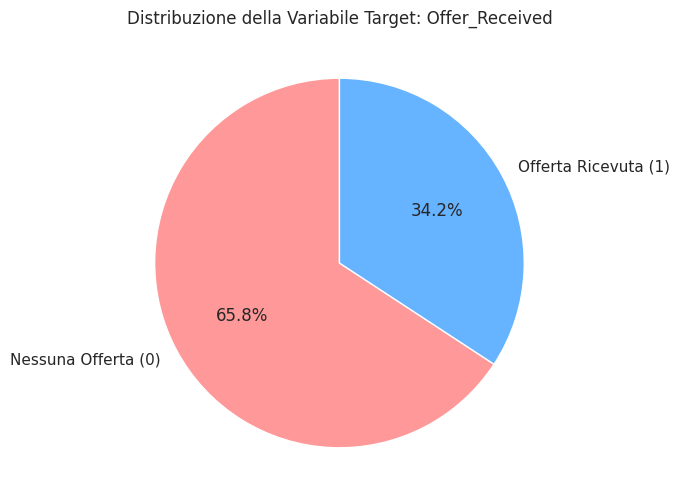

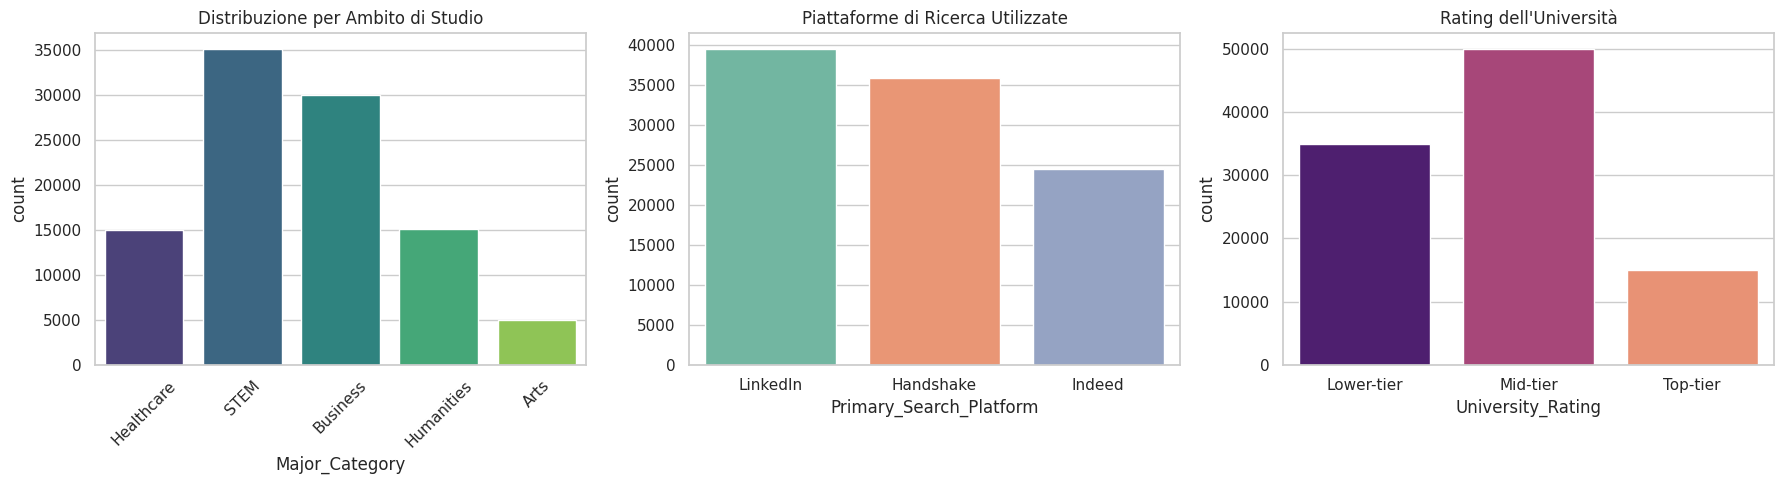

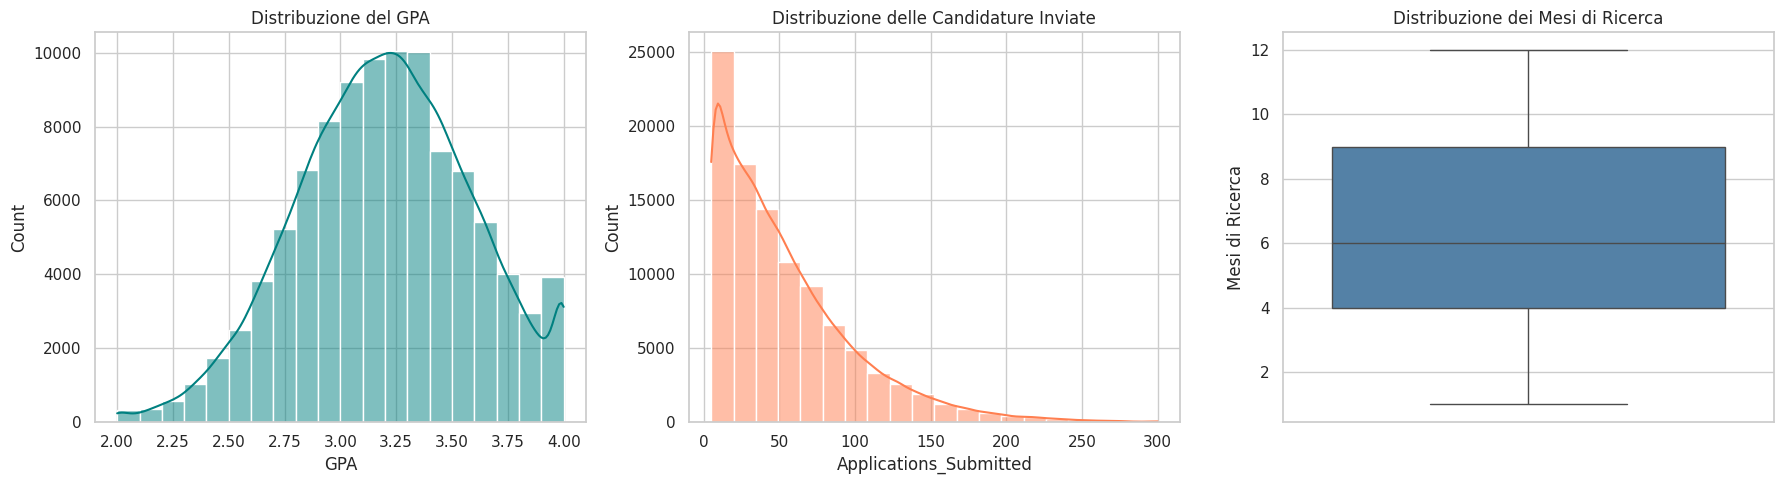

In [15]:
# Grafico a Torta per la Variabile Target
plt.figure(figsize=(6, 6))
offer_counts = df['Offer_Received'].value_counts()
plt.pie(offer_counts, labels=['Nessuna Offerta (0)', 'Offerta Ricevuta (1)'],
        autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Distribuzione della Variabile Target: Offer_Received')
plt.show()

# Grafici a barre per variabili categoriali
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='Major_Category', ax=axes[0], palette='viridis')
axes[0].set_title('Distribuzione per Ambito di Studio')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Primary_Search_Platform', ax=axes[1], palette='Set2')
axes[1].set_title('Piattaforme di Ricerca Utilizzate')

sns.countplot(data=df, x='University_Rating', ax=axes[2], palette='magma',
              order=['Lower-tier', 'Mid-tier', 'Top-tier'])
axes[2].set_title("Rating dell'Università")

plt.tight_layout()
plt.show()

# Istogrammi e Boxplot per le variabili numeriche principali
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x='GPA', kde=True, ax=axes[0], color='teal', bins=20)
axes[0].set_title('Distribuzione del GPA')

sns.histplot(data=df, x='Applications_Submitted', kde=True, ax=axes[1], color='coral', bins=20)
axes[1].set_title('Distribuzione delle Candidature Inviate')

sns.boxplot(data=df, y='Months_Searching', ax=axes[2], color='steelblue')
axes[2].set_title('Distribuzione dei Mesi di Ricerca')
axes[2].set_ylabel('Mesi di Ricerca')

plt.tight_layout()
plt.show()

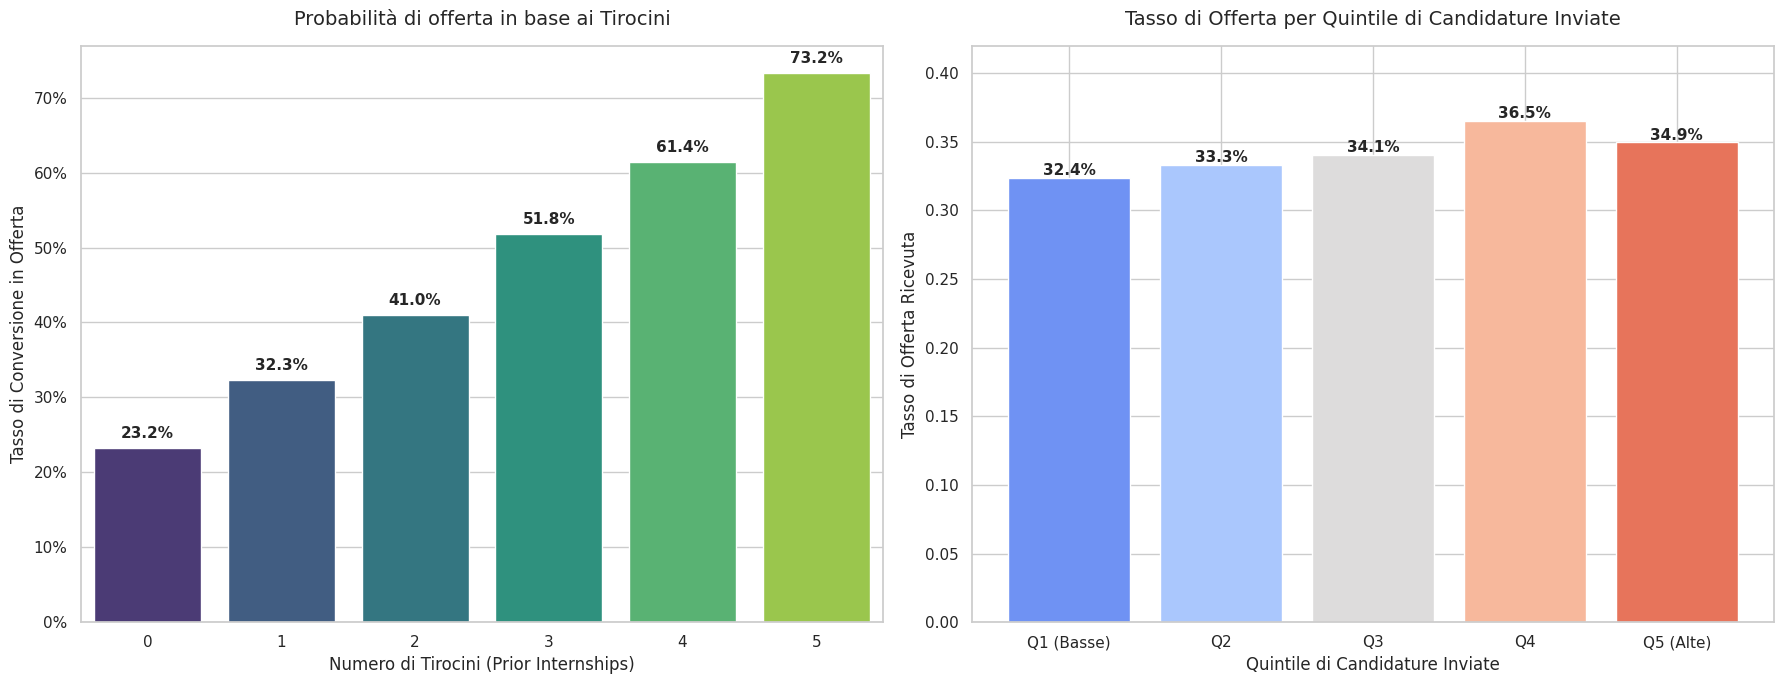

In [16]:
# Analisi del tasso di successo per tirocini e per numero di candidature
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Probabilità di offerta in base ai tirocini
sns.barplot(
    data=df, x='Prior_Internships', y='Offer_Received',
    palette='viridis', errorbar=None, ax=axes[0]
)
axes[0].set_title("Probabilità di offerta in base ai Tirocini", fontsize=14, pad=15)
axes[0].set_xlabel("Numero di Tirocini (Prior Internships)", fontsize=12)
axes[0].set_ylabel("Tasso di Conversione in Offerta", fontsize=12)

for p in axes[0].patches:
    altezza = p.get_height()
    axes[0].annotate(f"{altezza*100:.1f}%",
                     (p.get_x() + p.get_width() / 2., altezza),
                     ha='center', va='bottom', xytext=(0, 5),
                     textcoords='offset points', fontweight='bold', fontsize=11)

yticks = axes[0].get_yticks()
axes[0].set_yticklabels([f"{int(y*100)}%" for y in yticks])

# Probabilità di offerta per fasce di candidature inviate
df['App_Quintile'] = pd.qcut(df['Applications_Submitted'], q=5, labels=['Q1 (Basse)', 'Q2', 'Q3', 'Q4', 'Q5 (Alte)'])
success_by_apps = df.groupby('App_Quintile', observed=True)['Offer_Received'].mean()

axes[1].bar(success_by_apps.index, success_by_apps.values, color=sns.color_palette('coolwarm', 5))
axes[1].set_title("Tasso di Offerta per Quintile di Candidature Inviate", fontsize=14, pad=15)
axes[1].set_xlabel("Quintile di Candidature Inviate", fontsize=12)
axes[1].set_ylabel("Tasso di Offerta Ricevuta", fontsize=12)

for i, v in enumerate(success_by_apps.values):
    axes[1].text(i, v + 0.002, f"{v*100:.1f}%", ha='center', fontweight='bold', fontsize=11)

axes[1].set_ylim(0, success_by_apps.max() * 1.15)

plt.tight_layout()
plt.show()

**Commento ai risultati:**

* **L'Impatto dei Tirocini:** Il grafico mostra una relazione quasi perfettamente lineare tra l'esperienza pratica e la probabilità di assunzione. Uno studente senza tirocini ha circa il 25% di possibilità di ricevere un'offerta, ma questa probabilità sale progressivamente fino a quasi raddoppiare (~50%) per chi ha accumulato 4-5 tirocini. Questo evidenzia `Prior_Internships` come la feature legata al curriculum più preziosa.
* **Le Candidature Inviate:** Il tasso di offerta risulta sostanzialmente piatto tra i quintili di candidature inviate. Inviare molte candidature non garantisce un risultato migliore: la quantità non compensa la qualità del profilo.

### 2.2 Analisi delle Correlazioni
Studiamo come le variabili numeriche si relazionano tra loro e con il target tramite una Heatmap della matrice di correlazione di Pearson.

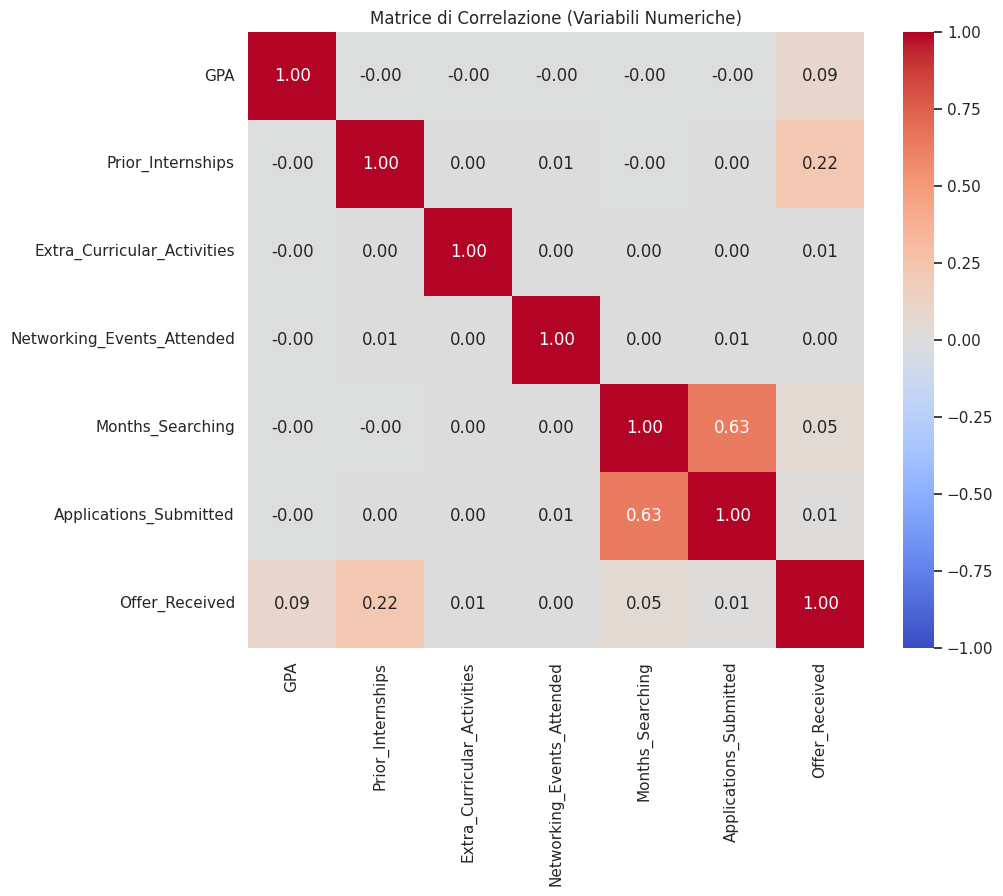

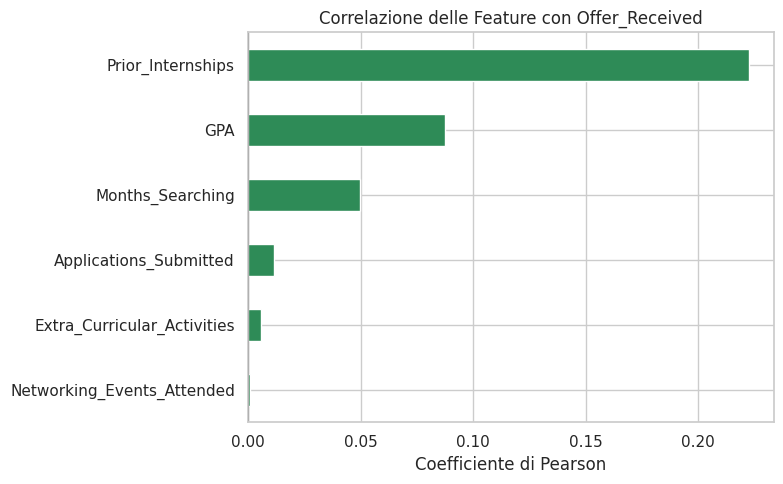

In [17]:
# Selezioniamo solo le colonne numeriche per la matrice di correlazione
colonne_numeriche = df.select_dtypes(include=[np.number]).drop(columns=['App_Quintile'], errors='ignore')

# Calcoliamo la matrice di correlazione
corr_matrix = colonne_numeriche.corr()

# Disegniamo la Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Matrice di Correlazione (Variabili Numeriche)')
plt.show()

# Grafico: correlazione con il target in ordine decrescente
corr_target = corr_matrix['Offer_Received'].drop('Offer_Received').sort_values()
colori = np.where(corr_target > 0, 'seagreen', 'indianred')

plt.figure(figsize=(8, 5))
corr_target.plot(kind='barh', color=colori)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title("Correlazione delle Feature con Offer_Received")
plt.xlabel("Coefficiente di Pearson")
plt.tight_layout()
plt.show()

**Analisi della Heatmap:**

* **`Prior_Internships` (≈ 0.22):** Emerge come il predittore lineare più forte tra le variabili rimaste. L'esperienza pratica pregressa è il segnale più affidabile di occupabilità.
* **`GPA` (≈ 0.10):** Una correlazione modesta ma positiva. Il voto di laurea conta, ma non è determinante da solo.
* **`Extra_Curricular_Activities` (≈ 0.06) e `Networking_Events_Attended` (≈ 0.05):** Correlazioni debolissime con il target. Le attività extracurriculari e il networking hanno un impatto lineare molto limitato.
* **`Applications_Submitted` e `Months_Searching` (≈ 0.03):** Praticamente correlazione nulla con il target, coerente con quanto osservato nel grafico per quintili: la quantità pura di candidature non predice il successo.

**Conclusione:** Senza le feature di leakage, il dataset mostra segnali predittivi deboli. Predire il successo nel placement da soli fattori pre-processo è intrinsecamente difficile.

## 3. Preparazione dei dati (Data Preprocessing)

In questa fase prepariamo il dataset affinché i modelli possano elaborarlo correttamente. Il primo step consiste nel trasformare le variabili categoriali in formato numerico:

1. **Variabili Ordinali (`School_Size`, `University_Rating`):** Avendo un ordine logico intrinseco (es. Small < Medium < Large), utilizziamo un `OrdinalEncoder` specificando esplicitamente l'ordine delle categorie.
2. **Variabili Nominali (`Region`, `Major_Category`, `Primary_Search_Platform`):** Applichiamo il *One-Hot Encoding* con `OneHotEncoder(drop='first')` per evitare la dummy variable trap (multicollinearità perfetta che destabilizzerebbe i modelli lineari come la Regressione Logistica).

In [18]:
# Rimuoviamo la colonna ausiliaria creata durante l'EDA
df = df.drop(columns=['App_Quintile'], errors='ignore')

numeric_features = [
    'GPA', 'Prior_Internships', 'Extra_Curricular_Activities',
    'Networking_Events_Attended', 'Applications_Submitted', 'Months_Searching'
]

# Per le variabili ordinali specifichiamo esplicitamente l'ordine delle categorie:
# OrdinalEncoder assegnerà 0, 1, 2 rispettando la gerarchia dichiarata.
ordinal_features   = ['School_Size', 'University_Rating']
ordinal_categories = [
    ['Small', 'Medium', 'Large'],
    ['Lower-tier', 'Mid-tier', 'Top-tier']
]

categorical_features = ['Region', 'Major_Category', 'Primary_Search_Platform']

print("Feature numeriche: ", numeric_features)
print("Feature ordinali:  ", ordinal_features)
print("Feature nominali:  ", categorical_features)
print(f"\nColonne totali nel df: {df.shape[1]} (incluso il target)")

Feature numeriche:  ['GPA', 'Prior_Internships', 'Extra_Curricular_Activities', 'Networking_Events_Attended', 'Applications_Submitted', 'Months_Searching']
Feature ordinali:   ['School_Size', 'University_Rating']
Feature nominali:   ['Region', 'Major_Category', 'Primary_Search_Platform']

Colonne totali nel df: 12 (incluso il target)


### 3.1 Isolamento del Target e Data Splitting
Separiamo la variabile obiettivo `Offer_Received` (y) dalle variabili predittive (X) e suddividiamo il dataset in Training Set (2/3) e Test Set (1/3) con campionamento stratificato per preservare il rapporto 34%/66%.

In [19]:
X = df.drop(columns=['Offer_Received'])
y = df['Offer_Received']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=1/3,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} record ({round(X_train.shape[0]/len(X)*100)}%)")
print(f"Test/Validation set: {X_test.shape[0]} record ({round(X_test.shape[0]/len(X)*100)}%)")
print(f"\nDistribuzione target nel training: {y_train.mean():.2%} positivi")
print(f"Distribuzione target nel test: {y_test.mean():.2%} positivi")

Training set: 66666 record (67%)
Test/Validation set: 33334 record (33%)

Distribuzione target nel training: 34.23% positivi
Distribuzione target nel test: 34.23% positivi


### 3.2 Standardizzazione dei Dati (Feature Scaling)
I modelli sensibili alla scala delle variabili (Perceptron, Regressione Logistica) richiedono che le feature siano centrate e normalizzate (es. una variabile come `Applications_Submitted` che arriva a 300 ridurrebbe l'importanza del `GPA` che varia tra 2 e 4).

Utilizziamo `StandardScaler` per centrare i dati rispetto alla media (media=0) e portarli a varianza unitaria (deviazione standard=1).

In [20]:
# remainder='drop' scarta eventuali colonne non elencate (non dovrebbero esservene).
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('ord', OrdinalEncoder(categories=ordinal_categories), ordinal_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
    ],
    remainder='drop'
)

# Tutti i modelli utilizzano class_weight='balanced' per pesare automaticamente
# le classi in proporzione inversa alla loro frequenza, compensando lo sbilanciamento 34/66.
pipeline_modelli = {
    "Perceptron (Baseline)": Pipeline([
        ('preprocessor', preprocessor),
        ('model', Perceptron(class_weight='balanced', random_state=42))
    ]),
    "Regressione Logistica": Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
    ]),
    "Albero Decisionale": Pipeline([
        ('preprocessor', preprocessor),
        # L'albero non è sensibile allo scaling, ma includerlo nella Pipeline
        # garantisce uniformità del flusso dati durante la cross-validation.
        ('model', DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=4))
    ]),
}

preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()
print(f"Feature prodotte dal preprocessore: {len(feature_names)}")
print(list(feature_names))


Feature prodotte dal preprocessore: 17
['num__GPA', 'num__Prior_Internships', 'num__Extra_Curricular_Activities', 'num__Networking_Events_Attended', 'num__Applications_Submitted', 'num__Months_Searching', 'ord__School_Size', 'ord__University_Rating', 'cat__Region_Northeast', 'cat__Region_South', 'cat__Region_West', 'cat__Major_Category_Business', 'cat__Major_Category_Healthcare', 'cat__Major_Category_Humanities', 'cat__Major_Category_STEM', 'cat__Primary_Search_Platform_Indeed', 'cat__Primary_Search_Platform_LinkedIn']


## 4. Addestramento, Validazione e Analisi dei Modelli

In questa fase procediamo all'addestramento dei tre modelli di classificazione selezionati: **Perceptron**, **Regressione Logistica** e **Albero Decisionale**.

Trattandosi di un problema di classificazione con un lieve sbilanciamento delle classi (34% vs 66%), non valuteremo i modelli solo tramite l'accuratezza globale, ma utilizzeremo:
- **Classification Report:** per analizzare Precision, Recall e F1-Score sulla classe positiva (quella minoritaria).
- **Matrice di Confusione:** per visualizzare la distribuzione degli errori (Falsi Positivi vs Falsi Negativi).

Inoltre utilizzeremo il parametro `class_weight = balanced` per penalizzare di più gli errori fatti sulla classe minoritaria.

Modello: Perceptron (Baseline)
Accuratezza Globale: 0.4731
              precision    recall  f1-score   support

           0       0.71      0.34      0.46     21924
           1       0.36      0.73      0.49     11410

    accuracy                           0.47     33334
   macro avg       0.54      0.53      0.47     33334
weighted avg       0.59      0.47      0.47     33334

Modello: Regressione Logistica
Accuratezza Globale: 0.6238
              precision    recall  f1-score   support

           0       0.75      0.64      0.69     21924
           1       0.46      0.59      0.52     11410

    accuracy                           0.62     33334
   macro avg       0.61      0.62      0.60     33334
weighted avg       0.65      0.62      0.63     33334

Modello: Albero Decisionale
Accuratezza Globale: 0.6467
              precision    recall  f1-score   support

           0       0.73      0.73      0.73     21924
           1       0.48      0.50      0.49     11410

    accu

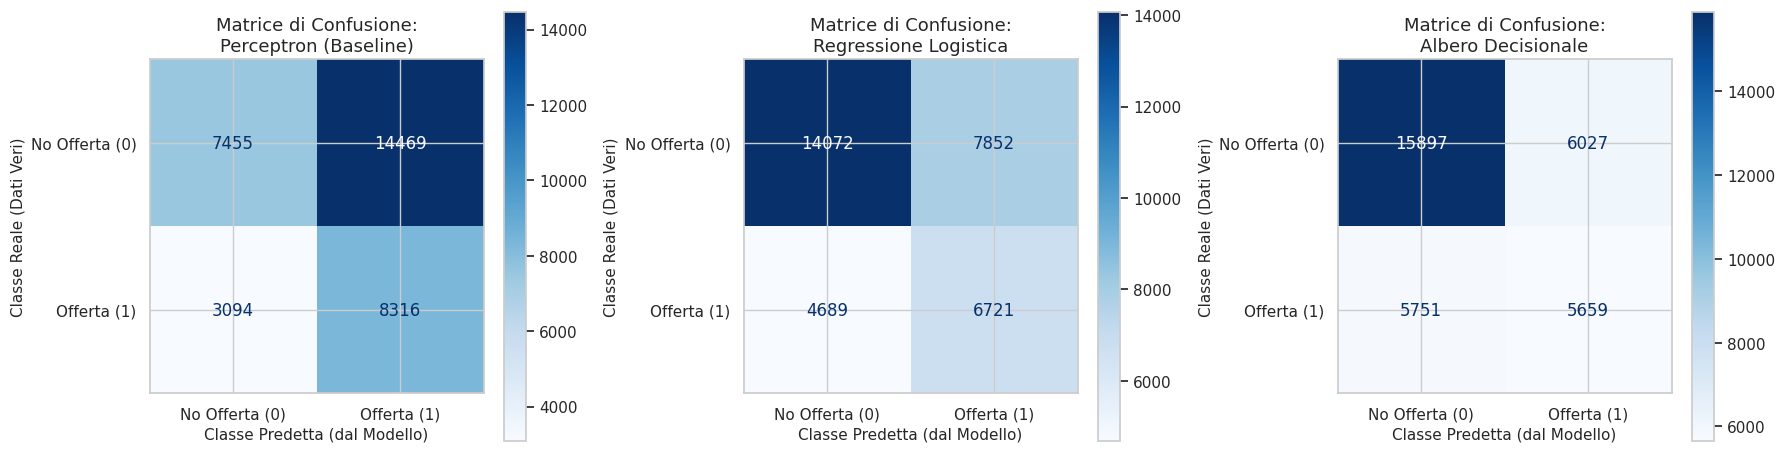

In [21]:
pipeline_addestrate = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (nome, pipeline) in enumerate(pipeline_modelli.items()):
    pipeline.fit(X_train, y_train)
    pipeline_addestrate[nome] = pipeline

    y_pred = pipeline.predict(X_test)

    print(f"Modello: {nome}")
    print(f"Accuratezza Globale: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['No Offerta (0)', 'Offerta (1)'],
        cmap='Blues', ax=axes[idx]
    )
    axes[idx].set_title(f'Matrice di Confusione:\n{nome}', fontsize=13)
    axes[idx].set_xlabel('Classe Predetta (dal Modello)', fontsize=11)
    axes[idx].set_ylabel('Classe Reale (Dati Veri)', fontsize=11)

plt.tight_layout()
plt.show()

### 4.1 Analisi interna dei modelli (Feature Importance e Coefficienti)

Andiamo a ispezionare i parametri interni dei modelli e quali variabili risultano più rilevanti:

1. **Regressione Logistica:** Analizziamo i pesi (coefficienti θ). Un coefficiente positivo alto indica che all'aumentare di quella variabile aumenta la probabilità di ricevere l'offerta.
2. **Albero Decisionale:** Analizziamo la Feature Importance, ovvero quanto ogni variabile contribuisce a ridurre l'incertezza (Impurità di Gini) durante la creazione dei bivi decisionali (nodi) dell'albero.

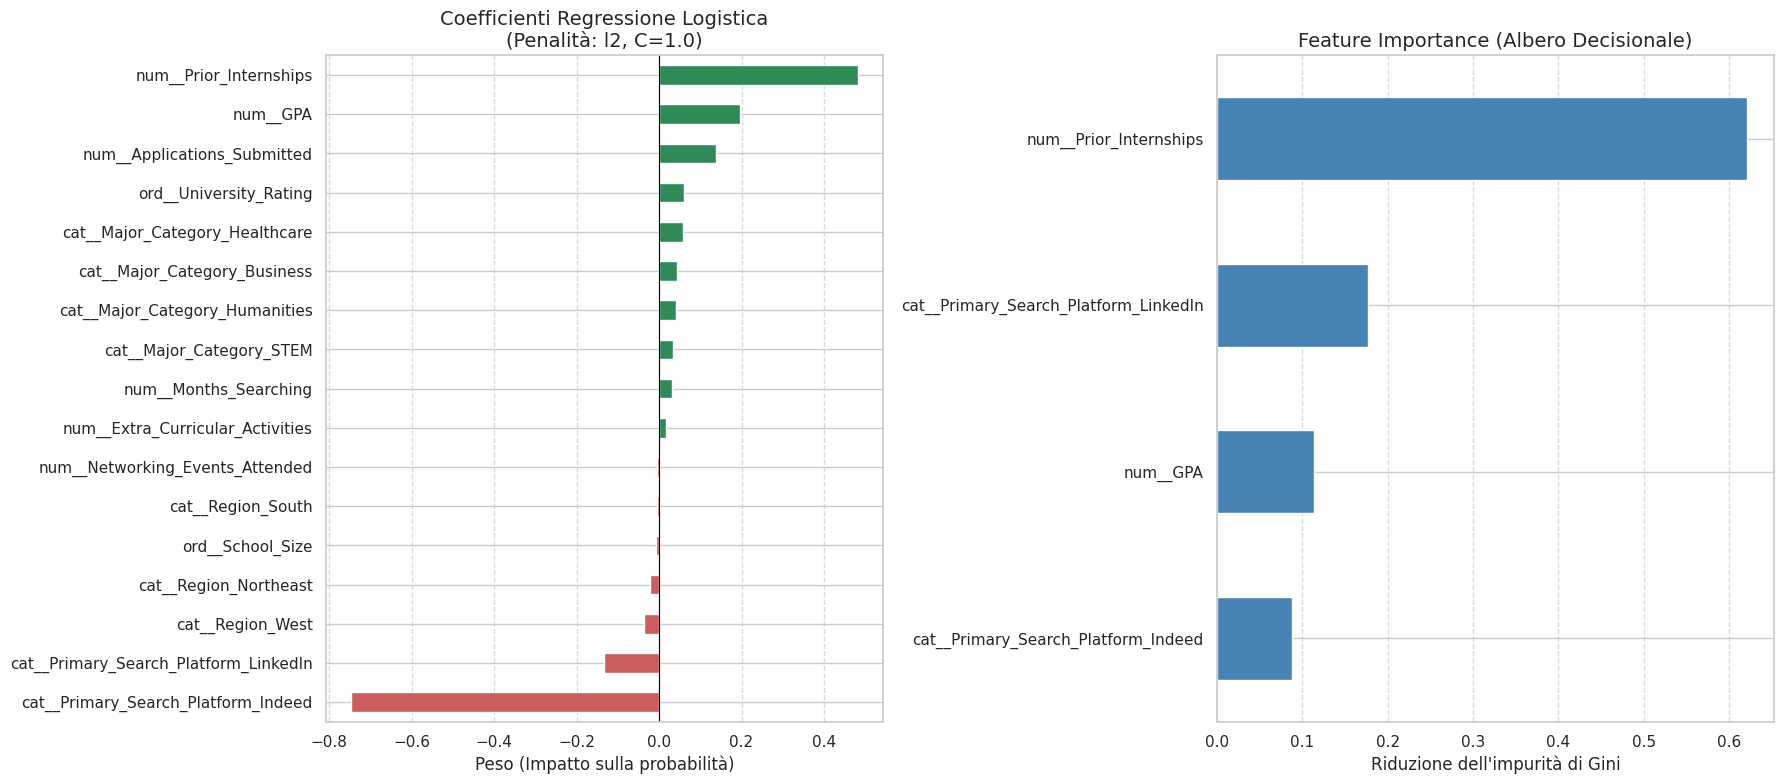

In [22]:
feature_names = pipeline_addestrate["Regressione Logistica"] \
                    .named_steps['preprocessor'] \
                    .get_feature_names_out()

logreg = pipeline_addestrate["Regressione Logistica"].named_steps['model']
dtree  = pipeline_addestrate["Albero Decisionale"].named_steps['model']

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Analisi Regressione Logistica
coefs = pd.Series(logreg.coef_[0], index=feature_names).sort_values()
colori_coef = np.where(coefs > 0, 'seagreen', 'indianred')

coefs.plot(kind='barh', ax=axes[0], color=colori_coef)
axes[0].set_title(f"Coefficienti Regressione Logistica\n(Penalità: {logreg.penalty}, C={logreg.C})", fontsize=14)
axes[0].set_xlabel("Peso (Impatto sulla probabilità)")
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Analisi Albero Decisionale
importances = pd.Series(dtree.feature_importances_, index=feature_names).sort_values()
importances = importances[importances > 0]

importances.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title("Feature Importance (Albero Decisionale)", fontsize=14)
axes[1].set_xlabel("Riduzione dell'impurità di Gini")
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 4.2 Interpretazione dei risultati e importanza delle variabili

**Performance Generali:**
Un modello che predice il placement da soli fattori pre-processo (curriculum, tirocini, candidature inviate) non può tenere conto della componente aleatoria che è presente nel job placement, il che rende l'accuratezza dei modelli non molto alta.

**Le variabili più influenti (Regressione Logistica):**
`Prior_Internships` emerge con il coefficiente positivo più marcato, confermando quanto emerso nell'EDA: l'esperienza pregressa è il segnale più forte. `GPA` e il networking contribuiscono positivamente in misura minore. Alcune variabili categoriali (Major, Region) mostrano effetti molto limitati, coerentemente con la loro scarsa correlazione con il target.

**Dinamiche non lineari (Albero Decisionale):**
L'albero mette in evidenza `Prior_Internships` come primo nodo di separazione, confermando il ruolo dominante di questa variabile.

## 5. Ottimizzazione degli Iperparametri (Grid Search CV)

In questa fase puntiamo a massimizzare le performance dei modelli tramite **Grid Search con Cross-Validation (K-Fold)**, testando in modo esaustivo diverse combinazioni di parametri sul Training Set.

Ottimizzeremo due modelli:
1. **Regressione Logistica:** Varieremo il parametro di regolarizzazione `C`.
2. **Albero Decisionale:** Esploreremo diverse profondità massime (`max_depth`) e il numero minimo di campioni per dividere un nodo (`min_samples_split`) per potare l'albero in modo ottimale.

La metrica di ottimizzazione è l'**F1-Score** sulla classe positiva, più robusta dell'accuratezza in presenza di classi sbilanciate.

In [29]:
# Grid Search Regressione Logistica
print("Grid Search: Regressione Logistica")

param_grid_lr = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
}

pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_lr = GridSearchCV(pipe_lr, param_grid_lr, scoring='f1', cv=skf, n_jobs=-1, verbose=1)
gs_lr.fit(X_train, y_train)

print(f"\nParametri ottimali: {gs_lr.best_params_}")
print(f"F1-Score migliore (CV): {gs_lr.best_score_:.4f}")

y_pred_lr = gs_lr.best_estimator_.predict(X_test)
print(f"\nRisultati sul Test Set:")
print(f"Accuratezza: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

Grid Search: Regressione Logistica
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Parametri ottimali: {'model__C': 10}
F1-Score migliore (CV): 0.5189

Risultati sul Test Set:
Accuratezza: 0.6237
              precision    recall  f1-score   support

           0       0.75      0.64      0.69     21924
           1       0.46      0.59      0.52     11410

    accuracy                           0.62     33334
   macro avg       0.61      0.62      0.60     33334
weighted avg       0.65      0.62      0.63     33334



In [30]:
#Grid Search Albero Decisionale
print("Grid Search: Albero Decisionale")

param_grid_dt = {
    'model__max_depth': [3, 5, 8, 10, 15, None],
    'model__min_samples_split': [2, 10, 50, 100, 200],
}

pipe_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('model',  DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

gs_dt = GridSearchCV(pipe_dt, param_grid_dt, scoring='f1', cv=skf, n_jobs=-1, verbose=1)
gs_dt.fit(X_train, y_train)

print(f"\nParametri ottimali: {gs_dt.best_params_}")
print(f"F1-Score migliore (CV): {gs_dt.best_score_:.4f}")

y_pred_dt = gs_dt.best_estimator_.predict(X_test)
print(f"\nRisultati sul Test Set:")
print(f"Accuratezza: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))

Grid Search: Albero Decisionale
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Parametri ottimali: {'model__max_depth': 5, 'model__min_samples_split': 2}
F1-Score migliore (CV): 0.5184

Risultati sul Test Set:
Accuratezza: 0.6110
              precision    recall  f1-score   support

           0       0.75      0.61      0.67     21924
           1       0.45      0.62      0.52     11410

    accuracy                           0.61     33334
   macro avg       0.60      0.61      0.60     33334
weighted avg       0.65      0.61      0.62     33334



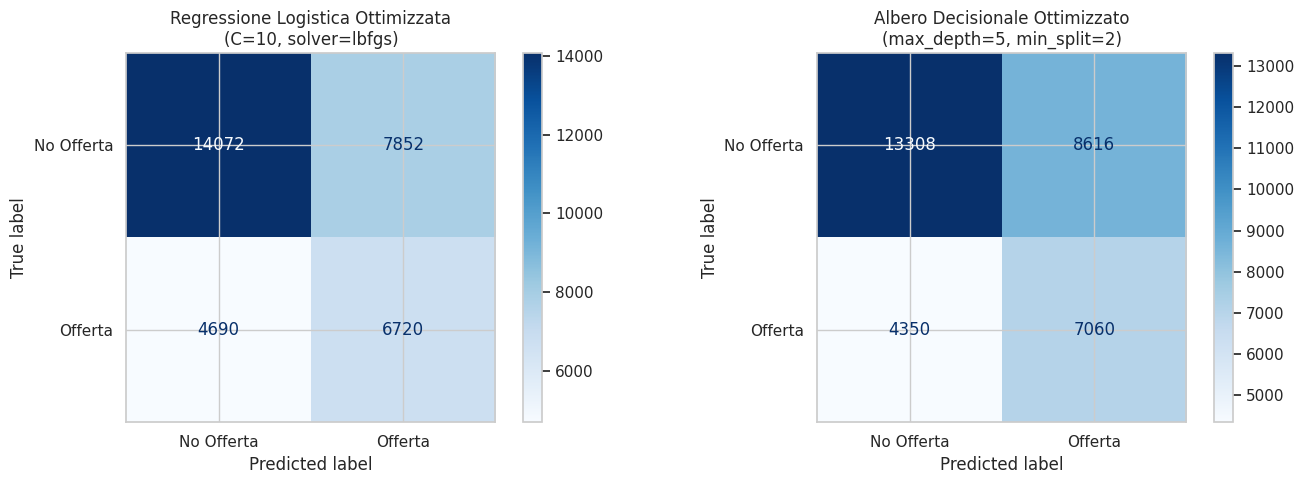

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['No Offerta', 'Offerta'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(
    f"Regressione Logistica Ottimizzata\n"
    f"(C={gs_lr.best_params_['model__C']}, solver={gs_lr.best_params_['model__solver']})"
)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['No Offerta', 'Offerta'],
    cmap='Blues', ax=axes[1]
)
axes[1].set_title(
    f"Albero Decisionale Ottimizzato\n"
    f"(max_depth={gs_dt.best_params_['model__max_depth']}, "
    f"min_split={gs_dt.best_params_['model__min_samples_split']})"
)

plt.tight_layout()
plt.show()


### 5.1 Interpretazione dei Risultati del Grid Search

Dopo l'ottimizzazione degli iperparametri, sia la Regressione Logistica che l'Albero Decisionale mostrano performance simili e in linea con i risultati iniziali. L'F1-Score, metriche chiave per il nostro problema con classi sbilanciate, rimane intorno al 52% per entrambi i modelli.

*   **Regressione Logistica Ottimizzata:**
    *   Accuratezza: 0.6237
    *   F1-Score (classe 1): 0.52
    *   La matrice di confusione mostra un bilanciamento tra Falsi Positivi e Falsi Negativi, con un leggero miglioramento nel riconoscimento della classe positiva (Offerta Ricevuta) rispetto al Perceptron.

*   **Albero Decisionale Ottimizzato:**
    *   Accuratezza: 0.6110
    *   F1-Score (classe 1): 0.52
    *   Anche l'Albero Decisionale mantiene un F1-Score simile, suggerendo che la complessità del modello non migliora significativamente la predizione della classe positiva senza l'aggiunta di nuove informazioni.

**Considerazioni:**

Entrambi i modelli, pur essendo ottimizzati, continuano a non essere molto precisi nel predire in modo robusto la ricezione di un'offerta di lavoro, specialmente a causa della natura intrinseca del problema e della mancanza di feature altamente predittive nello scenario 'Pre-Search'. L'equilibrio tra precisione e recall per la classe positiva è ancora una sfida, come evidenziato dal valore di F1-Score.

## 6. Confronto con Scenario Mid-Search (variabili colloquio incluse)

Come analisi supplementare, misuriamo l'impatto della decisione di escludere `First_Round_Interviews` e `Second_Round_Interviews` confrontando le performance dei modelli nei due scenari:

| Scenario | Feature disponibili | Domanda a cui risponde |
|---|---|---|
| **Pre-Search** | Solo profilo accademico e comportamentale | *"Dato il mio profilo, riuscirò ad avere un'offerta?"* |
| **Mid-Search** | Tutte, inclusi i round di colloquio | *"Dato lo stato attuale della mia ricerca, riceverò un'offerta?"* |

La differenza di performance tra i due scenari quantifica il contributo informativo dei round di colloquio rispetto al solo profilo dello studente.

In [36]:
df_mid = pd.read_csv('job_board_effectiveness.csv')
df_mid = df_mid.drop(columns=[
    'Student_ID', 'Time_to_Offer_Days', 'Offer_Salary',
    'Company_Size_Offered', 'Role_Relevance', 'Accepted_Offer'
])

numeric_mid = [
    'GPA', 'Prior_Internships', 'Extra_Curricular_Activities',
    'Networking_Events_Attended', 'Applications_Submitted',
    'Months_Searching', 'First_Round_Interviews', 'Second_Round_Interviews'
]
ordinal_mid = ['School_Size', 'University_Rating']
ordinal_cats = [['Small','Medium','Large'], ['Lower-tier','Mid-tier','Top-tier']]
categorical_mid = ['Region', 'Major_Category', 'Primary_Search_Platform']

X_mid = df_mid.drop(columns=['Offer_Received'])
y_mid = df_mid['Offer_Received']

X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_mid, y_mid, test_size=1/3, random_state=42, stratify=y_mid
)

pre_mid = ColumnTransformer([
    ('num', StandardScaler(), numeric_mid),
    ('ord', OrdinalEncoder(categories=ordinal_cats), ordinal_mid),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_mid),
], remainder='drop')

modelli_mid = {
    "Perceptron (Baseline)": Pipeline([('preprocessor', pre_mid), ('model', Perceptron(class_weight='balanced', random_state=42))]),
    "Regressione Logistica": Pipeline([('preprocessor', pre_mid), ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))]),
    "Albero Decisionale": Pipeline([('preprocessor', pre_mid), ('model', DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=4))]),
}

risultati_mid = {}
for nome, pipe in modelli_mid.items():
    pipe.fit(X_tr_m, y_tr_m)
    yp = pipe.predict(X_te_m)
    risultati_mid[nome] = {
        'accuracy': accuracy_score(y_te_m, yp),
        'f1': f1_score(y_te_m, yp)
    }

risultati_pre = {}
for nome, pipe in pipeline_addestrate.items():
    yp = pipe.predict(X_test)
    risultati_pre[nome] = {
        'accuracy': accuracy_score(y_test, yp),
        'f1': f1_score(y_test, yp)
    }

print(f"{'Modello':<30} {'Pre-Search Acc':>15} {'Pre-Search F1':>14} {'Mid-Search Acc':>15} {'Mid-Search F1':>14}")
for nome in risultati_pre:
    p = risultati_pre[nome]
    m = risultati_mid[nome]
    print(f"{nome:<30} {p['accuracy']:>15.4f} {p['f1']:>14.4f} {m['accuracy']:>15.4f} {m['f1']:>14.4f}")

Modello                         Pre-Search Acc  Pre-Search F1  Mid-Search Acc  Mid-Search F1
Perceptron (Baseline)                   0.4731         0.4864          0.7287         0.6955
Regressione Logistica                   0.6238         0.5173          0.8067         0.7306
Albero Decisionale                      0.6467         0.4900          0.8303         0.8013


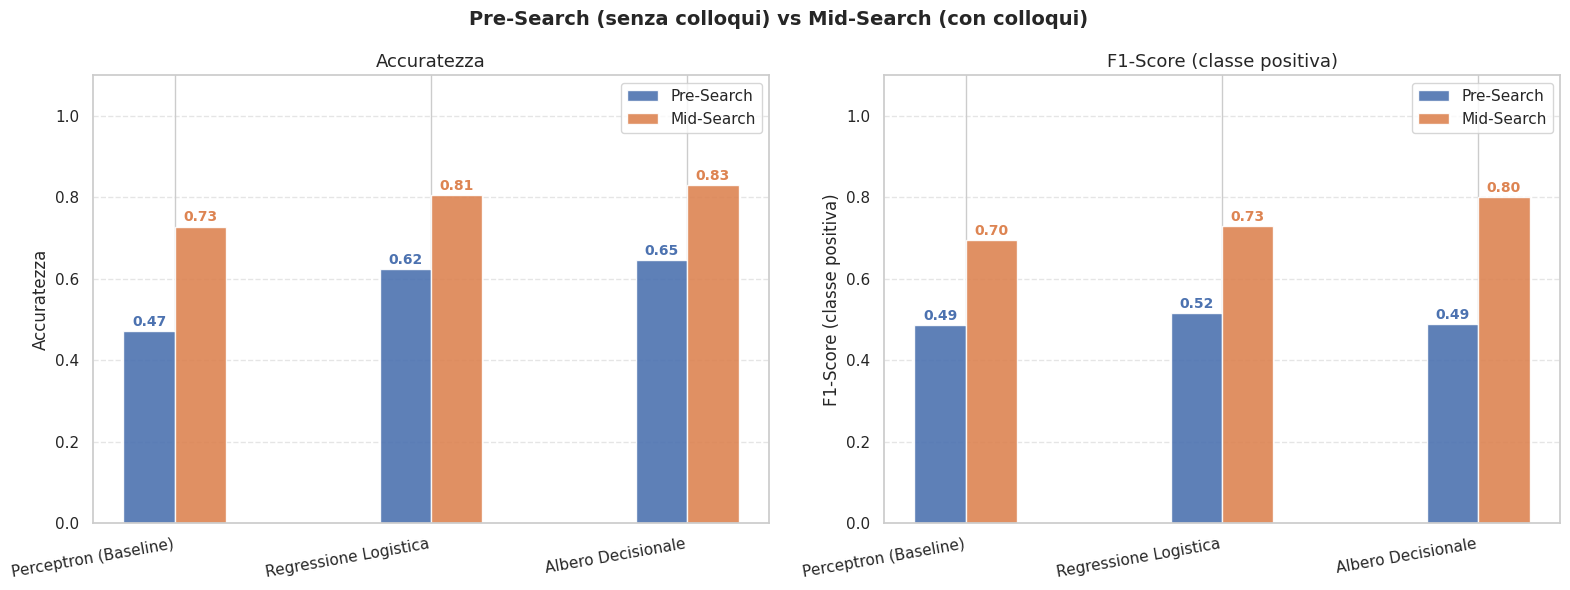

In [33]:
nomi = list(risultati_pre.keys())
x = np.arange(len(nomi))
width = 0.2
colori = {'pre': '#4C72B0', 'mid': '#DD8452'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Pre-Search (senza colloqui) vs Mid-Search (con colloqui)',
    fontsize=14, fontweight='bold'
)

for ax, metrica, label in zip(axes, ['accuracy', 'f1'], ['Accuratezza', 'F1-Score (classe positiva)']):
    vals_pre = [risultati_pre[n][metrica] for n in nomi]
    vals_mid = [risultati_mid[n][metrica] for n in nomi]

    b_pre = ax.bar(x - width/2, vals_pre, width, label='Pre-Search', color=colori['pre'], alpha=0.9)
    b_mid = ax.bar(x + width/2, vals_mid, width, label='Mid-Search', color=colori['mid'], alpha=0.9)

    for bars, col in [(b_pre, colori['pre']), (b_mid, colori['mid'])]:
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width()/2, h + 0.005,
                    f"{h:.2f}", ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color=col)

    ax.set_title(label, fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(nomi, rotation=10, ha='right')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 6.1 Interpretazione del Confronto

Il gap di performance tra i due scenari è netto e conferma numericamente quanto anticipato dalla leak detection.

**Entità del divario:** includere i round di colloquio alza sensibilmente F1 e accuratezza su tutti e tre i modelli, con l'effetto più marcato sull'Albero Decisionale.

**I due modelli non sono in competizione:** rispondono a domande diverse. Il modello pre-search presentato nelle sezioni principali è metodologicamente più onesto e utile per un career advisor o per politiche universitarie di orientamento. Il modello mid-search avrebbe senso in un'applicazione in tempo reale, dove lo studente aggiorna le proprie probabilità man mano che avanza nei colloqui ma richiederebbe una raccolta dati attiva durante il processo, non a posteriori.

## 7. Conclusioni

Questo progetto ha affrontato la previsione del successo nel placement universitario partendo da un dataset di 100.000 studenti, con l'obiettivo di costruire un modello che stimi la probabilità di ricevere un'offerta di lavoro basandosi sul profilo accademico e comportamentale del candidato.

**Scelte metodologiche chiave**

La decisione più rilevante del progetto è stata la rimozione di `First_Round_Interviews` e `Second_Round_Interviews`, motivata da un'analisi quantitativa di leak detection (ROC-AUC univariato rispettivamente di 0.71 e 0.86). Pur non trattandosi di data leakage in senso classico (i colloqui avvengono prima dell'offerta nel processo di hiring), includerle avrebbe reso il modello meno "onesto". Il confronto nella Sezione 6 ha quantificato questo effetto, mostrando il gap di performance tra lo scenario mid-search e quello pre-search.

**Cosa predicono i modelli**

L'analisi delle feature importance e dei coefficienti ha prodotto una gerarchia coerente tra tutti i modelli: `Prior_Internships` è il predittore curricolare dominante, seguito da `GPA` e `University_Rating`. Le variabili comportamentali di ricerca (`Applications_Submitted`, `Networking_Events_Attended`) contribuiscono marginalmente. Si ricava che l'esperienza pratica pregressa è l'investimento più redditizio per chi si prepara all'ingresso nel mercato del lavoro, più della quantità di candidature inviate o del networking.

**Limiti e sviluppi futuri**

Le performance dei modelli pre-search (accuratezze intorno al 62-65% e F1 intorno a 0.50-0.52) riflettono la difficoltà intrinseca del problema: il mercato del lavoro ha una componente di variabilità che nessun algoritmo può eliminare a partire dal solo profilo dello studente. Possibili miglioramenti futuri includono l'utilizzo di modelli ensemble più potenti (XGBoost, Random Forest) o l'integrazione di feature aggiuntive che catturino aspetti qualitativi del profilo non presenti nel dataset attuale.